In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as ps
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker

import torch
import pandas as pd
import torch.nn as nn
import optuna
from models import CondSM
from pathlib import Path
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 9,    # affects horizontal colorbar ticks
    "ytick.labelsize": 9,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 9,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

print(pd.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

def fit_affine_to_target(y_sm: torch.Tensor, y_tgt: torch.Tensor, eps: float = 1e-12, clamp_gain_nonneg: bool = False):
    """
    Fit a,b minimizing ||a*y_sm + b - y_tgt||^2 (least squares with intercept).
    Returns: (a, b, y_aff)
    """
    if not torch.is_tensor(y_sm):
        y_sm = torch.as_tensor(y_sm)
    if not torch.is_tensor(y_tgt):
        y_tgt = torch.as_tensor(y_tgt)
        
    y = y_sm.float().flatten()
    t = y_tgt.float().flatten()

    y_mean = y.mean()
    t_mean = t.mean()

    y0 = y - y_mean
    t0 = t - t_mean

    var_y = (y0 * y0).mean()
    cov_yt = (y0 * t0).mean()

    a = cov_yt / (var_y + eps)
    if clamp_gain_nonneg:
        a = torch.clamp(a, min=0.0)

    b = t_mean - a * y_mean
    y_aff = a * y_sm + b
    return a, b, y_aff

def mse(a, b):
    """Mean squared error between two 1D arrays/tensors."""
    if not torch.is_tensor(a):
        a = torch.as_tensor(a)
    if not torch.is_tensor(b):
        b = torch.as_tensor(b)
    a = a.float().flatten()
    b = b.float().flatten()
    return torch.mean((a - b) ** 2)

2.2.3
cuda


original curve mse: tensor(0.0814)


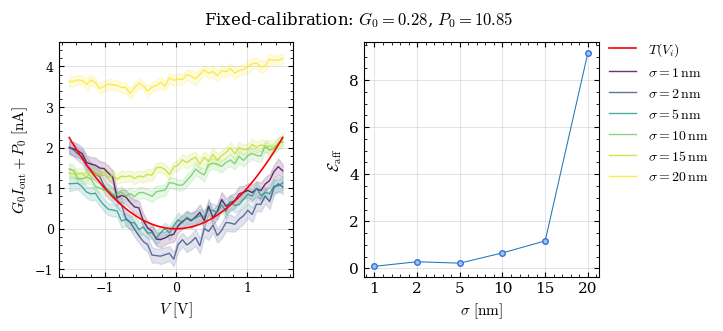

In [278]:
data_type = 'data_vMB_ring_1e7'
func_type = 'Parabola'

n = 50
x = torch.linspace(-1.5, 1.5, n)
if func_type == 'Parabola':
    y_tgt = x ** 2
elif func_type == 'ReLU':
    m = nn.ReLU()
    y_tgt = m(x)
elif func_type == 'Sigmoid':
    m = nn.Sigmoid()
    y_tgt = m(4*x)
elif func_type == 'Cubic':
    y_tgt = x **3
elif func_type == 'Sine':
    y_tgt = torch.sin(3*x)

dopant_profile_path = Path(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/final_datasets/{data_type}/configs/jiggled_configs/')

i_scale = 1e21
noise_strengths = [1, 2, 5, 10, 15, 20]
noise_vals = np.array(noise_strengths)

ref_data = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/{data_type}_{func_type}_jiggling/random_mse_func_type={func_type}_data_type={data_type}_jiggled_k=0.npz")
i_ref = ref_data['current'] * i_scale
gain_global, offset_global, i_aff_global = fit_affine_to_target(i_ref, y_tgt)
gain_global, offset_global = gain_global.numpy(), offset_global.numpy()

cal_mode = 'global'    

d_profiles = []
i_outs = []
i_errs = []
e_aff_scores = []
gains = []
offsets = []
for k in range(len(noise_strengths)):
    d_profiles.append(np.loadtxt(Path(dopant_profile_path / f"jiggled_{k}.txt")))
    data_k = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/{data_type}_{func_type}_jiggling/random_mse_func_type={func_type}_data_type={data_type}_jiggled_k={k}.npz")
    i_o = data_k['current'] * i_scale
    i_err = data_k['sem'] * i_scale
    g_0 = 0.0
    p_0 = 0.0
    if cal_mode == 'global':
        i_o_aff = i_o * gain_global + offset_global
        i_err_aff = i_err * np.abs(gain_global)
    elif cal_mode == 'recal':
        g_0, p_0, i_o_aff = fit_affine_to_target(i_o, y_tgt)
        g_0, p_0, i_o_aff = g_0.numpy(), p_0.numpy(), i_o_aff.numpy()
        i_err_aff = i_err * np.abs(g_0)
    gains.append(g_0)
    offsets.append(p_0)
        
    e_aff = mse(i_o_aff, y_tgt)
    e_aff_scores.append(e_aff)
    
    i_outs.append(i_o_aff)
    i_errs.append(i_err_aff)

data_no_noise = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/random_mse_func_type={func_type}_data_type={data_type}_maxl2=2.0_input_idx=3_seed=42.npz')
i_org = data_no_noise['current'] * i_scale
i_err_org = data_no_noise['sem'] * i_scale

g_0_org, p_org_0, i_org_aff = fit_affine_to_target(i_org, y_tgt)
g_0_org, p_org_0, i_org_aff = g_0_org.numpy(), p_org_0.numpy(), i_org_aff.numpy()
print("original curve mse:", mse(y_tgt, i_org_aff))

i_err_org = i_err_org * np.abs(g_0_org)

"""fig, ax = plt.subplots(ncols=2, figsize=(5, 5))
ax.minorticks_on()
ax.tick_params(top=True, right=True, which='both')
ax.tick_params(direction='in', which='both')
ax.grid(lw=0.5, alpha=0.5)
ax.set_box_aspect(1)"""

fig, ax = plt.subplots(ncols=2, figsize=(8, 4))
for a in ax:
    a.minorticks_on()
    a.tick_params(top=True, right=True, which='both')
    a.tick_params(direction='in', which='both')
    a.grid(lw=0.5, alpha=0.5)
    a.set_box_aspect(1)

#ax.plot(np.linspace(-1.5, 1.5, 50), i_org_aff, lw=2.5, c='r', alpha=0.5, label='$\sigma = 0 \, \mathrm{nm}$')
#ax.fill_between(np.linspace(-1.5, 1.5, 50), i_org_aff - i_err_org*1.96, i_org_aff + i_err_org*1.96, alpha=0.15)
#ax.plot(np.linspace(-1.5, 1.5, 50), i_org_aff, lw=5, alpha=0.5, label='$\sigma = 0 \, \mathrm{nm}$', zorder=6)
ax[0].plot(np.linspace(-1.5, 1.5, 50), y_tgt, lw=1.2, c='r', label='$T(V_i)$', zorder=5)
ax[0].set_xlabel("$V \, \, [\mathrm{V}]$")
ax[0].set_ylabel("$G_0 I_{\mathrm{out}} + P_0 \, \, [\mathrm{nA}]$")

"""axins = inset_axes(ax, width="30%", height="30%", loc="upper left", borderpad=1.)
axins.tick_params(which='both', direction='in', labelsize=9)
#axins.tick_params(axis='y', labelrotation=90)
axins.tick_params(axis='x', labelbottom=True, labeltop=False)
axins.set_xticks(np.arange(1, len(noise_strengths)+1, 1))
axins.set_xticklabels([str(ns) for ns in noise_strengths])
axins.set_xlabel('$\sigma \, \, [\mathrm{nm}]$', fontsize=9)
axins.xaxis.set_label_position('bottom')
axins.yaxis.set_label_position('right')
axins.tick_params(axis='y', labelleft=False, labelright=True)
axins.set_ylabel('$\mathcal{E}_{\mathrm{aff}}$')
axins.minorticks_on()
axins.tick_params(top=True, right=True, which='both')
axins.set_yscale('log')
axins.grid(lw=0.5, alpha=0.5, which='both', axis='y')
axins.grid(lw=0.5, alpha=0.5, which='major', axis='x')

axins.plot(np.arange(1, len(noise_strengths)+1, 1), e_aff_scores, marker="o", lw=0.75, markersize=4, markeredgecolor='royalblue', markerfacecolor='skyblue')"""

def ten_e_formatter(val, pos=None):
    # val is the tick value (e.g., 0.01)
    if val <= 0:
        return ""
    exp = int(round(np.log10(val)))
    # Only label exact powers of 10 (major ticks)
    if np.isclose(val, 10**exp):
        return f"10e{exp}"   # e.g. 10e-2
    return ""

axins = ax[1]
axins.tick_params(which='both', direction='in', labelsize=11)
#axins.tick_params(axis='y', labelrotation=90)
axins.tick_params(axis='x', labelbottom=True, labeltop=False)
axins.set_xticks(np.arange(1, len(noise_strengths)+1, 1))
axins.set_xticklabels([str(ns) for ns in noise_strengths])
axins.set_xlabel('$\sigma \, \, [\mathrm{nm}]$', fontsize=11)
axins.xaxis.set_label_position('bottom')
axins.yaxis.set_label_position('left')
axins.tick_params(axis='y', labelleft=True, labelright=False)
axins.set_ylabel('$\mathcal{E}_{\mathrm{aff}}$', fontsize=11)
axins.minorticks_on()
axins.tick_params(top=True, right=True, which='both')
#axins.set_yscale('log')
axins.grid(lw=0.5, alpha=0.5, which='major', axis='y')
axins.grid(lw=0.5, alpha=0.5, which='major', axis='x')

axins.plot(np.arange(1, len(noise_strengths)+1, 1), e_aff_scores, marker="o", lw=0.75, markersize=4, markeredgecolor='royalblue', markerfacecolor='skyblue')

#axins.yaxis.set_major_locator(mticker.LogLocator(base=10))
#axins.yaxis.set_major_formatter(mticker.FuncFormatter(ten_e_formatter))
#axins.yaxis.set_minor_formatter(mticker.NullFormatter())

cmap = plt.get_cmap('viridis')
norm = mpl.colors.LogNorm(vmin=noise_vals.min(), vmax=noise_vals.max())

for i in range(len(noise_strengths)):
    ax[0].fill_between(np.linspace(-1.5, 1.5, 50), i_outs[i] - i_errs[i]*1.96, i_outs[i] + i_errs[i]*1.96, alpha=0.15, color=cmap(norm(noise_vals[i])))
    ax[0].plot(np.linspace(-1.5, 1.5, 50), i_outs[i], lw=1., alpha=0.8, label=rf'$\sigma={noise_strengths[i]} \, \mathrm{{nm}}$', color=cmap(norm(noise_vals[i])))
    
#axins_pos = axins.get_position()
#axins.set_position([axins_pos.x0+0.02, axins_pos.y0, axins_pos.width, axins_pos.height])+
ax[0].legend(ncols=1, bbox_to_anchor=(2.82, 1.06), title_fontsize=7, frameon=False)
if cal_mode == 'global':
    fig.suptitle(f"Fixed-calibration: $G_0={gain_global:.2f}$, $P_0={offset_global:.2f}$", y=0.87, fontsize=12, ha='center')
elif cal_mode == 'recal':
    fig.suptitle("Re-calibration", y=0.87, fontsize=12, ha='center')
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
#cbar = fig.colorbar(sm, ax=ax, pad=0.02)
#cbar.set_label(r'$\sigma \, [\mathrm{nm}]$')
#fig.subplots_adjust(wspace=.3)
fig.subplots_adjust(wspace=0.3, right=0.8)
fig.savefig(f'{cal_mode}_{data_type}_{func_type}.pdf')

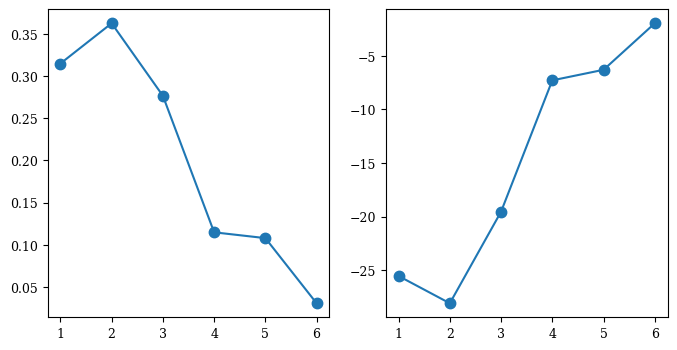

In [272]:
fig, ax = plt.subplots(ncols=2, figsize=(8, 4))
ax[0].plot(np.arange(1, len(gains)+1, 1), gains, marker='o', markersize=7.5)
ax[1].plot(np.arange(1, len(offsets)+1, 1), offsets, marker='o', markersize=7.5)